El presente análisis utiliza técnicas de procesamiento de lenguaje natural (NLP) para diferenciar textos generados por inteligencia artificial de aquellos escritos por humanos. El objetivo es evaluar si a partir de embeddings y modelos de clasificación es posible encontrar patrones que permitan distinguir ambos tipos de texto.

1. Intalacion e importacion de librerias

In [ ]:
! python -m spacy download en_core_web_sm
! pip install -U symspellpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 23.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk # importar natural language toolkit
nltk.download('punkt')
nltk.download('stopwords') # modulo para descargar stopwords en diferentes idiomas
nltk.download('wordnet')
from nltk.corpus import stopwords
import pandas as pd
import numpy  as np
import re
import string
import plotly
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer
import time
import spacy
import en_core_web_sm
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from nltk.probability import FreqDist
from wordcloud import WordCloud
import pickle
from symspellpy import SymSpell
import pkg_resources
from symspellpy import SymSpell, Verbosity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import en_core_web_md
nlp = en_core_web_md.load()





2. Descarga del documento desde google drive.

In [ ]:
!gdown 1Tu-D-_W_ROQCVqwHt3KU0PqyTjqw2c-x


Downloading...
From: https://drive.google.com/uc?id=1Tu-D-_W_ROQCVqwHt3KU0PqyTjqw2c-x
To: /content/balanced_ai_human_prompts.csv
100% 4.62M/4.62M [00:00<00:00, 150MB/s]


3. Observamos como está compuesto el dataset

In [ ]:
import pandas as pd

df = pd.read_csv("balanced_ai_human_prompts.csv")
print(df.head())



                                                text  generated
0  Machine learning, a subset of artificial intel...          1
1  A decision tree, a prominent machine learning ...          1
2  Education, a cornerstone of societal progress,...          1
3  Computers, the backbone of modern technology, ...          1
4  Chess, a timeless game of strategy and intelle...          1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2750 non-null   object
 1   generated  2750 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [ ]:
df['generated'].value_counts(normalize=True)


,proportion
generated,
1,0.5
0,0.5


4. Vemos que hay muchos textos cortos

<Axes: >

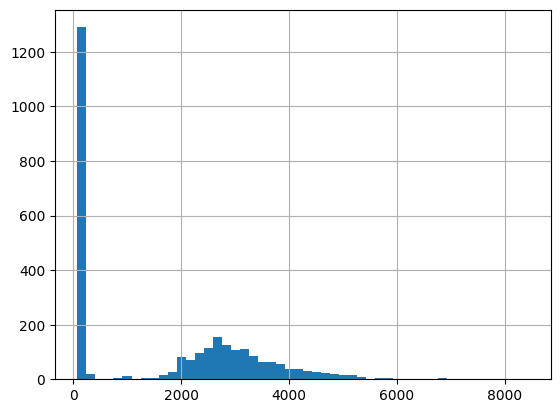

In [ ]:
df['text_length'] = df['text'].apply(len)
df['text_length'].hist(bins=50)


In [ ]:
short_texts = (df['text_length'] < 100).sum()
long_texts = (df['text_length'] > df['text_length'].median()).sum()

print("Textos muy cortos (<100 chars):", short_texts)
print("Textos más largos que la mediana:", long_texts)


Textos muy cortos (<100 chars): 980
Textos más largos que la mediana: 1375


5. Hacemos el preprocesamiento del texto

In [ ]:
from nltk.corpus import stopwords
import string
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Conversion a minúsculas
    text = text.lower()

    # Eliminacion de puntuacion
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Procesado con spacy
    doc = nlp(text)

    # Lematización + remocion de stopwords
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_space]

    return " ".join(tokens)

# Aplicado al dataset
df['clean_text'] = df['text'].apply(preprocess_text)

# ejemplo
print(df[['text', 'clean_text']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0  Machine learning, a subset of artificial intel...   
1  A decision tree, a prominent machine learning ...   
2  Education, a cornerstone of societal progress,...   
3  Computers, the backbone of modern technology, ...   
4  Chess, a timeless game of strategy and intelle...   

                                          clean_text  
0  machine learn subset artificial intelligence r...  
1  decision tree prominent machine learn algorith...  
2  education cornerstone societal progress extend...  
3  computer backbone modern technology revolution...  
4  chess timeless game strategy intellect transce...  


6. Creamos la variable objetivo

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
X = df['clean_text']  # textos preprocesados
y = df['generated']   # 0 = Humano
                      # 1 = IA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


7.Utilizamos Td-idf y entrenamos un modelo de regresión logistica

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)  # limitamos el vocabulario a 5000 palabras más frecuentes
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

8. Vemos que el modelo responde muy bien en Regresion Logistica

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.990909090909091

Confusion Matrix:
 [[281   3]
 [  2 264]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       284
           1       0.99      0.99      0.99       266

    accuracy                           0.99       550
   macro avg       0.99      0.99      0.99       550
weighted avg       0.99      0.99      0.99       550



9. Vemos como funciona con una frase de ejemplo

In [ ]:
# Tomamos una frase del dataset
ejemplo = df.iloc[10]
frase = ejemplo['text']
print("Texto original:", frase)
print("Etiqueta real (0=Humano, 1=IA):", ejemplo['generated'])

# Texto de ejemplo
frase_clean = [preprocess_text(frase)]
frase_tfidf = vectorizer.transform(frase_clean)

# Predicción con el modelo TF-IDF
pred = model.predict(frase_tfidf)[0]
prob = model.predict_proba(frase_tfidf)[0]

print("Texto original:", frase)
print("Etiqueta real (0=Humano, 1=IA):", ejemplo['generated'])
print("Predicción TF-IDF:", pred)
print("Probabilidades [Humano, IA]:", prob)



Texto original: Cellphones, ubiquitous in our daily lives, epitomize the convergence of communication, computing, and entertainment. Evolving from simple communication devices, modern smartphones have become pocket-sized powerhouses, featuring advanced processors, high-resolution displays, and sophisticated camera systems. Beyond traditional calls and texts, smartphones enable seamless internet access, social media engagement, and a vast array of applications. The app ecosystem, characteristic of smartphones, has revolutionized industries, from healthcare to education. As devices shrink in size and expand in functionality, concerns about privacy, digital addiction, and electronic waste emerge. Yet, cellphones fundamentally connect people globally, shaping how we navigate information, socialize, and navigate the digital landscape. In an era of rapid technological advancement, cellphones continue to redefine the way we communicate and experience the world.
Etiqueta real (0=Humano, 1=IA):

10. Hacemos la predicción con un transformer, "distilbert-base-uncased"

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Modelo y tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

# Función para obtener embedding de una frase
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embeddings

# Aplicamos embeddings al dataset
X_embeddings = np.vstack(df['text'].apply(get_embedding))
y = df['generated']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.2, random_state=42)

# Clasificador
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy (DistilBERT Embeddings):", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy (DistilBERT Embeddings): 0.9963636363636363

Confusion Matrix:
 [[284   0]
 [  2 264]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       284
           1       1.00      0.99      1.00       266

    accuracy                           1.00       550
   macro avg       1.00      1.00      1.00       550
weighted avg       1.00      1.00      1.00       550



11.Vemos como funciona con la misma frase

In [ ]:
# Misma frase
frase = ejemplo['text']

# Obtener embedding
embedding = get_embedding(frase).reshape(1, -1)

# Predicción
pred = clf.predict(embedding)[0]
prob = clf.predict_proba(embedding)[0]

print("Predicción Transformer:", pred)
print("Probabilidades [Humano, IA]:", prob)


Predicción Transformer: 1
Probabilidades [Humano, IA]: [5.66492074e-04 9.99433508e-01]


Conclusiones

Podemos ver que el Transformer tuvo mucha mas eficiencia en predecir que el TF-IDF

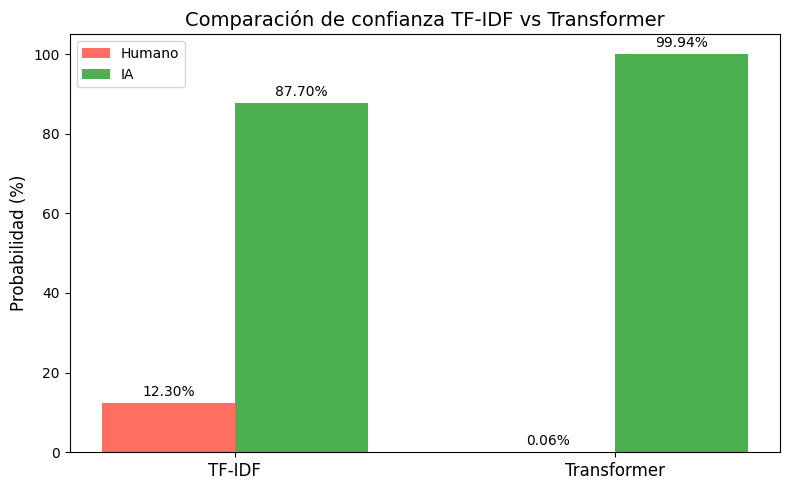

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
modelos = ['TF-IDF', 'Transformer']
prob_humano = [0.12301746, 0.00056649]
prob_ia = [0.87698254, 0.99943351]

# Convertir a porcentaje
prob_humano = [p * 100 for p in prob_humano]
prob_ia = [p * 100 for p in prob_ia]

x = np.arange(len(modelos))  # posiciones
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Barras
barras1 = ax.bar(x - width/2, prob_humano, width, label='Humano', color='#FF6F61')
barras2 = ax.bar(x + width/2, prob_ia, width, label='IA', color='#4CAF50')

# Etiquetas y título
ax.set_ylabel('Probabilidad (%)', fontsize=12)
ax.set_title('Comparación de confianza TF-IDF vs Transformer', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=12)
ax.legend()

# Mostrar valores encima de las barras
for barra in barras1 + barras2:
    height = barra.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()
